**TASK 3: CREDIT CARD FRAUD DETECTION**

**Task Description**

- **Build a machine learning model to identify fraudulent credit card transactions.**
- **Preprocess and normalize the transaction data, handle class imbalance issues, and split the dataset into training and testing sets.**
- **Train a classification algorithm, such as logistic regression or random forests, to classify transactions as fraudulent or genuine.**
- **Evaluate the model's performance using metrics like precision, recall, and F1-score, and consider techniques like oversampling or undersampling for improving results.**

**Task Description**

**Importing Libraries for Data Collection and Preprocessing**

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
dataset = pd.read_csv("creditcard.csv", encoding="latin1")
dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# Getting the number of rows and columns in the DataFrame
dataset.shape

(284807, 31)

In [9]:
# Display the data type of each column
dataset.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [10]:
# Displaying the last entries in the DataFrame
dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [11]:
# column titles (headers) of your dataset
dataset.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
# Display summary information about the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
# Checking summary statistics of numerical columns in the data
dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Exploring and Understanding the Dataset**

In [13]:
# Summarize null values in each feature
dataset.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

**After checking for missing entries, it was confirmed that all columns are complete and there are no null values present.**

In [14]:
# Quick overview of central tendency and spread
dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**EDA (Exploratory Data Analysis):**

- **EDA helps in understanding the structure, patterns, and anomalies within the dataset before applying machine learning models.**

- **It involves examining data distributions, relationships between features, and identifying missing or inconsistent values.**

- **Through EDA, we gain insights that guide preprocessing, feature selection, and model-building decisions.**

In [15]:
# Show the headers of the dataset
dataset.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [16]:
# Identify the different labels present in Class
dataset['Class'].unique()

array([0, 1])

**Formula**

**The Class column contains two possible values:**

**0 → Valid (non-fraud transaction)**
**1 → Fraud (fraudulent transaction)**

**To determine the number of fraud cases:**

**Number of Fraud Cases = ∑(Class=1)**

In [17]:
fraud_case = dataset[dataset['Class'] == 1]
valid_case = dataset[dataset['Class'] == 0]

print(f"Number of Fraud Cases: {len(fraud_case)}")
print(f"Number of Valid Cases: {len(valid_case)}")

# Fraud ratio compared to total
fraud_ratio = len(fraud_case) / len(dataset)
print(f"Fraud Cases Percentage: {fraud_ratio * 100:.4f}%")

Number of Fraud Cases: 492
Number of Valid Cases: 284315
Fraud Cases Percentage: 0.1727%


In [18]:
# Percentage of fraud cases
per = (len(fraud_case) / len(dataset['Class'])) * 100
print(f"Fraud Cases Percentage: {per:.4f}%")

Fraud Cases Percentage: 0.1727%


**Fraudulent cases account for only 0.17% of the total transactions.**

**Distribution of Classes**

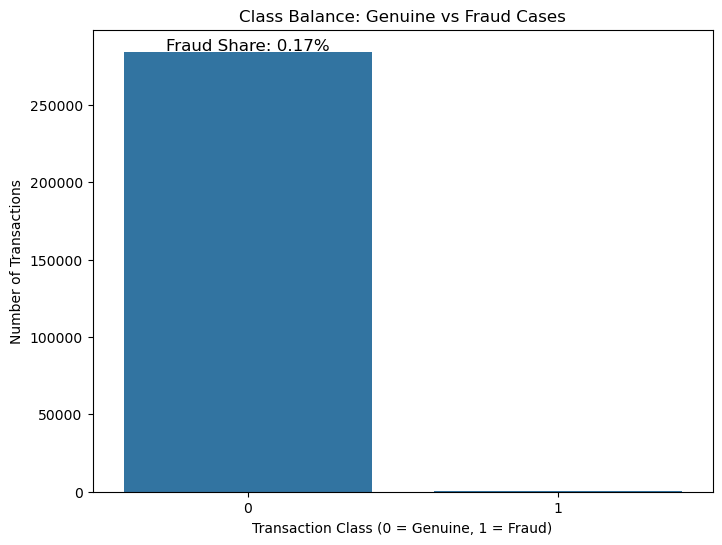

In [20]:
# Get the frequency of each class (0 = Genuine, 1 = Fraud)
class_distribution = dataset['Class'].value_counts()

# Derive the fraud percentage from total transactions
fraud_share = (class_distribution[1] / class_distribution.sum()) * 100

plt.figure(figsize=(8, 6))
sns.countplot(data=dataset, x='Class')
plt.title('Class Balance: Genuine vs Fraud Cases')
plt.xlabel('Transaction Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Number of Transactions')

# Add annotation showing the fraud percentage
plt.text(0, class_distribution[0] + 1000, 
         f'Fraud Share: {fraud_share:.2f}%', 
         fontsize=12, ha='center')

plt.show()

**Time-based Transaction Trends**

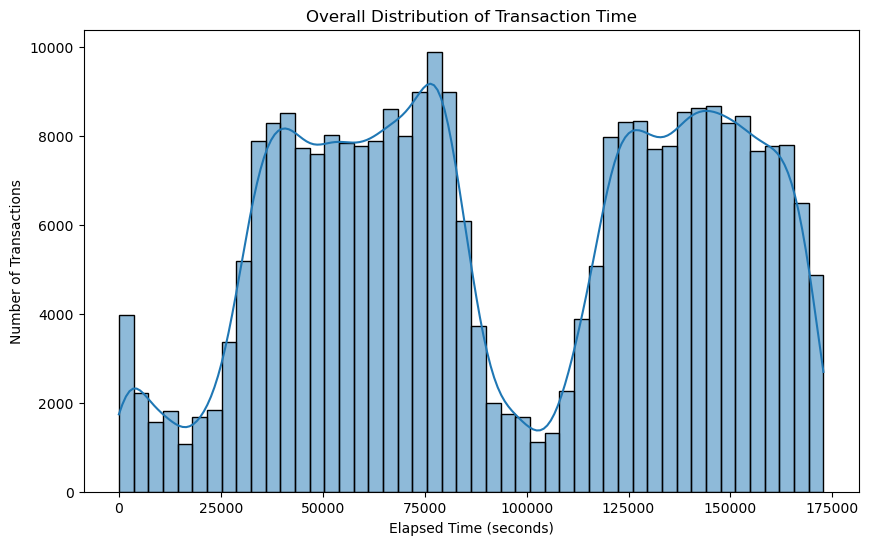

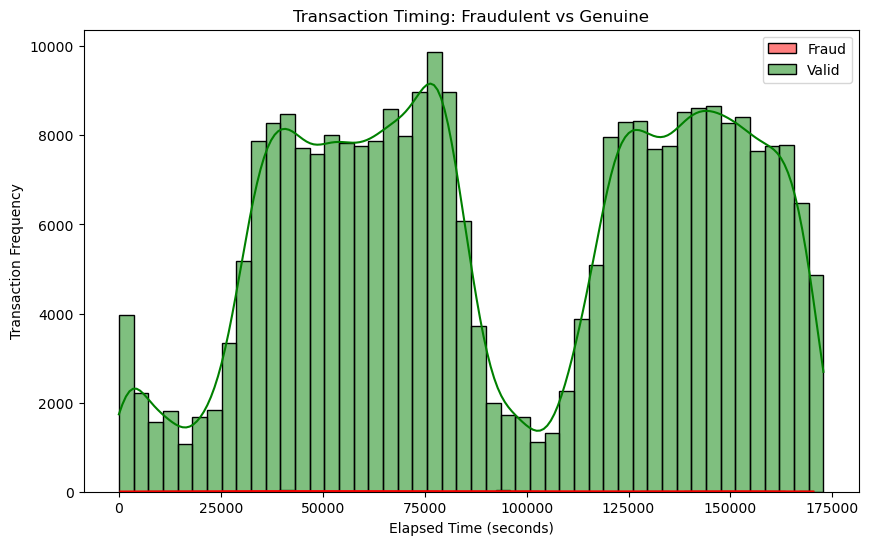

In [21]:
plt.figure(figsize=(10, 6))
# Histogram for overall transaction times
sns.histplot(dataset['Time'], bins=48, kde=True)
plt.title('Overall Distribution of Transaction Time')
plt.xlabel('Elapsed Time (seconds)')
plt.ylabel('Number of Transactions')

# Compare timing of fraud vs valid transactions
plt.figure(figsize=(10, 6))
sns.histplot(dataset[dataset['Class'] == 1]['Time'], bins=48, kde=True, color='red', label='Fraud')
sns.histplot(dataset[dataset['Class'] == 0]['Time'], bins=48, kde=True, color='green', label='Valid')
plt.title('Transaction Timing: Fraudulent vs Genuine')
plt.xlabel('Elapsed Time (seconds)')
plt.ylabel('Transaction Frequency')
plt.legend()

plt.show()

**Exploration of Transaction Amounts**

In [23]:
# Split dataset into legitimate and fraudulent transactions
legitimate_transactions = dataset[dataset['Class'] == 0]
fraudulent_transactions = dataset[dataset['Class'] == 1]

# Generate descriptive statistics for both groups
valid_stats = legitimate_transactions.describe()
fraud_stats = fraudulent_transactions.describe()

print("Descriptive Metrics for Valid Transactions:")
print(valid_stats)
print("\nDescriptive Metrics for Fraudulent Transactions:")
print(fraud_stats)

Descriptive Metrics for Valid Transactions:
                Time             V1             V2             V3  \
count  284315.000000  284315.000000  284315.000000  284315.000000   
mean    94838.202258       0.008258      -0.006271       0.012171   
std     47484.015786       1.929814       1.636146       1.459429   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54230.000000      -0.917544      -0.599473      -0.884541   
50%     84711.000000       0.020023       0.064070       0.182158   
75%    139333.000000       1.316218       0.800446       1.028372   
max    172792.000000       2.454930      18.902453       9.382558   

                  V4             V5             V6             V7  \
count  284315.000000  284315.000000  284315.000000  284315.000000   
mean       -0.007860       0.005453       0.002419       0.009637   
std         1.399333       1.356952       1.329913       1.178812   
min        -5.683171    -113.743307     -26.160506     -31

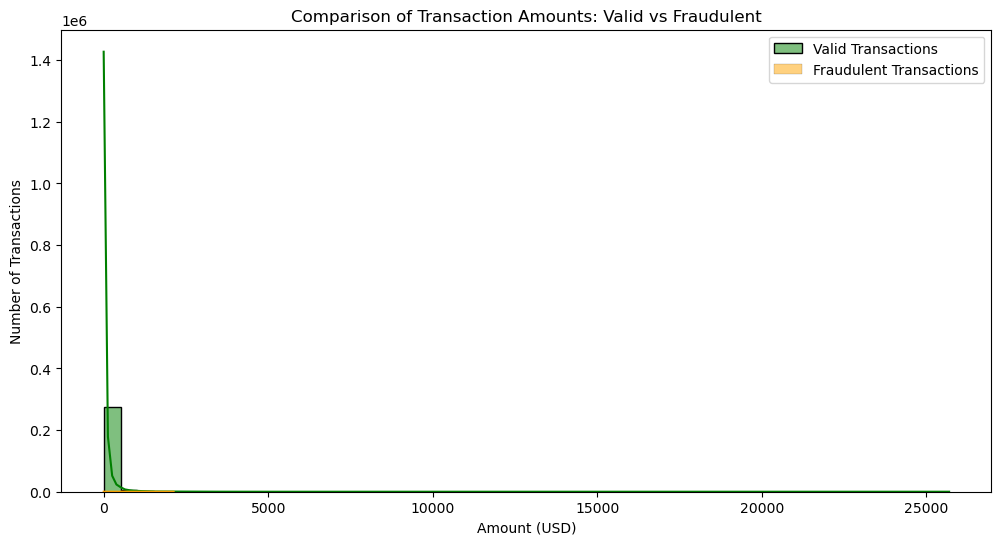

In [24]:
# Split transaction amounts into valid and fraud categories
valid_amounts = dataset[dataset['Class'] == 0]['Amount']
fraud_amounts = dataset[dataset['Class'] == 1]['Amount']

plt.figure(figsize=(12, 6))

# Distribution for valid transactions
sns.histplot(valid_amounts, bins=50, color='green', kde=True, label='Valid Transactions')

# Distribution for fraudulent transactions
sns.histplot(fraud_amounts, bins=50, color='orange', kde=True, label='Fraudulent Transactions')

plt.title('Comparison of Transaction Amounts: Valid vs Fraudulent')
plt.xlabel('Amount (USD)')
plt.ylabel('Number of Transactions')
plt.legend()

plt.show()

**Correlation of Dataset Attributes**

In [28]:
# Generate correlation matrix for the dataset
corr_matrix = dataset.corr()
print(corr_matrix)

# Extract correlation values of features with the target variable 'Class'
class_correlations = corr_matrix['Class'].drop('Class')
print(class_correlations)

# Set threshold for significant correlation
threshold = 0.1
important_features = class_correlations[abs(class_correlations) > threshold]


            Time            V1            V2            V3            V4  \
Time    1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1      0.117396  1.000000e+00  4.135835e-16 -1.227819e-15 -9.215150e-16   
V2     -0.010593  4.135835e-16  1.000000e+00  3.243764e-16 -1.121065e-15   
V3     -0.419618 -1.227819e-15  3.243764e-16  1.000000e+00  4.711293e-16   
V4     -0.105260 -9.215150e-16 -1.121065e-15  4.711293e-16  1.000000e+00   
V5      0.173072  1.812612e-17  5.157519e-16 -6.539009e-17 -1.719944e-15   
V6     -0.063016 -6.506567e-16  2.787346e-16  1.627627e-15 -7.491959e-16   
V7      0.084714 -1.005191e-15  2.055934e-16  4.895305e-16 -4.104503e-16   
V8     -0.036949 -2.433822e-16 -5.377041e-17 -1.268779e-15  5.697192e-16   
V9     -0.008660 -1.513678e-16  1.978488e-17  5.568367e-16  6.923247e-16   
V10     0.030617  7.388135e-17 -3.991394e-16  1.156587e-15  2.232685e-16   
V11    -0.247689  2.125498e-16  1.975426e-16  1.576830e-15  3.459380e-16   
V12     0.12

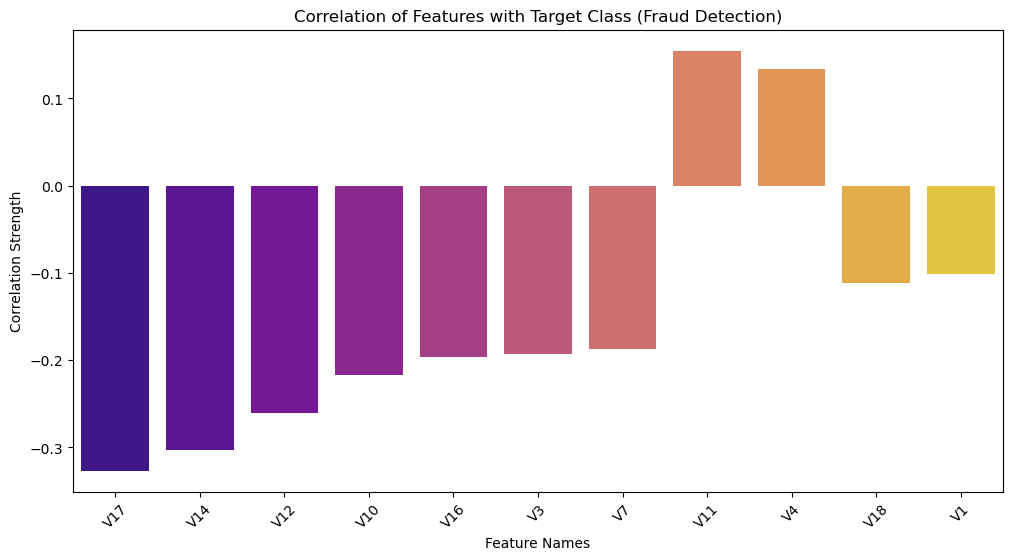

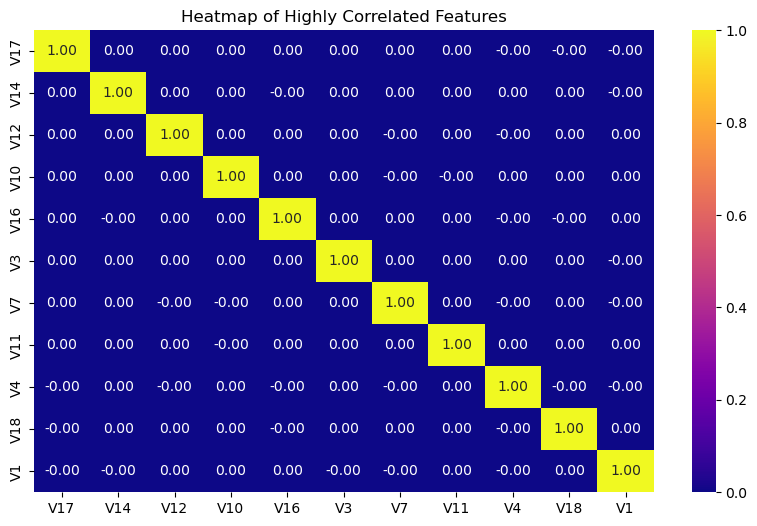

In [29]:
# Step 1: Compute correlation matrix
corr_matrix = dataset.corr()

# Step 2: Get correlations of features with target variable "Class"
class_correlations = corr_matrix['Class'].drop('Class')

# Step 3: Filter significant correlations (threshold = 0.1)
threshold = 0.1
important_features = class_correlations[abs(class_correlations) > threshold]

# Step 4: Sort features by correlation strength
important_features = important_features.sort_values(key=abs, ascending=False)

# BAR PLOT

plt.figure(figsize=(12, 6))
sns.barplot(
    x=important_features.index,
    y=important_features.values,
    hue=important_features.index,   # avoid future warning
    palette="plasma",
    legend=False
)

plt.title('Correlation of Features with Target Class (Fraud Detection)')
plt.xlabel('Feature Names')
plt.ylabel('Correlation Strength')
plt.xticks(rotation=45)
plt.show()

# HEATMAP 

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix.loc[important_features.index, important_features.index],
    annot=True,
    cmap="plasma",
    fmt=".2f"
)

plt.title("Heatmap of Highly Correlated Features")
plt.show()

**Relationship Between Transaction Value and Time**

**1. Scatter Plot of Time vs. Transaction Amount**

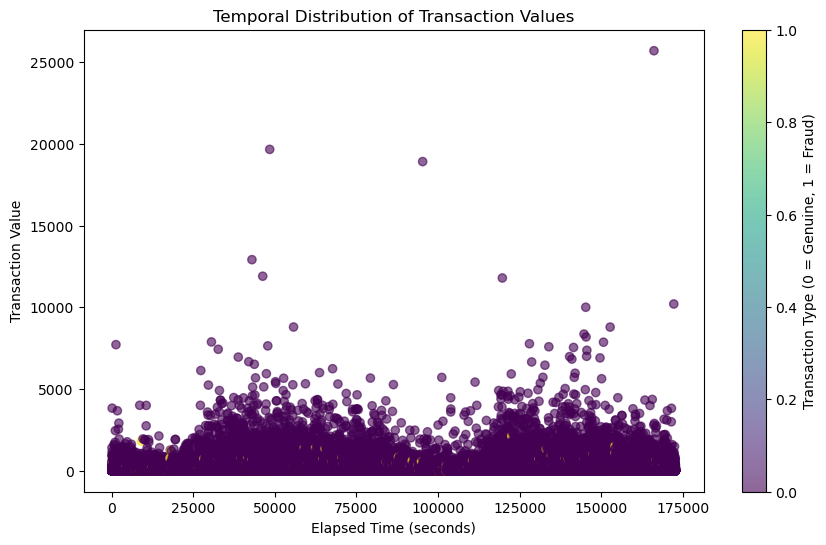

In [30]:
plt.figure(figsize=(10, 6))

# Scatter plot of transaction amounts over time
plt.scatter(
    x=dataset['Time'], 
    y=dataset['Amount'], 
    c=dataset['Class'], 
    cmap='viridis',   # changed color map
    alpha=0.6
)

plt.title('Temporal Distribution of Transaction Values')
plt.xlabel('Elapsed Time (seconds)')
plt.ylabel('Transaction Value')
plt.colorbar(label='Transaction Type (0 = Genuine, 1 = Fraud)')

plt.show()

**2. Heatmap of Feature-to-Feature Correlations**

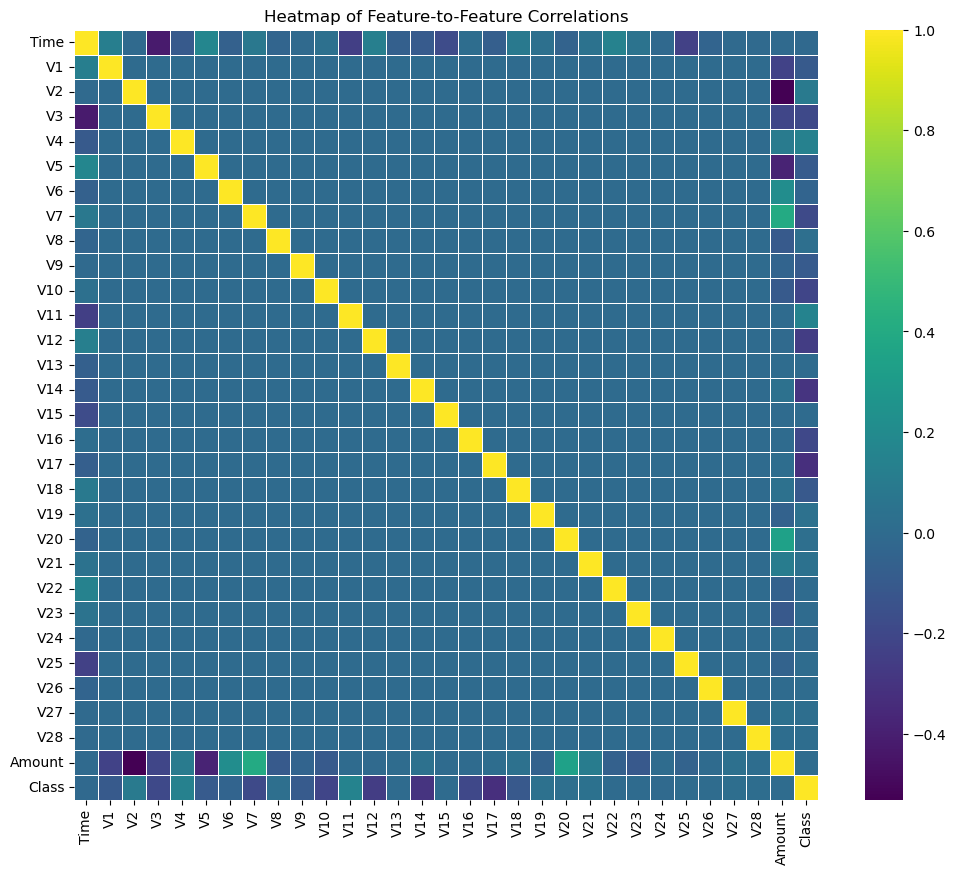

In [31]:
# Compute the correlation matrix
corr_matrix = dataset.corr()

# Plot heatmap for feature correlations
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    cmap='viridis',   # changed colormap
    annot=False, 
    fmt=".2f", 
    linewidths=0.4
)

plt.title('Heatmap of Feature-to-Feature Correlations')
plt.show()

**4. Fraud Detection Model Implementation**

In [32]:
# Build Classification Model
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)

**5. Defining and Spliting**

**Defining X and Y**

**- X → contains all the independent variables (features like Time, Amount, V1…V28)**

**- Y → contains the dependent variable (the Class column → 0 = valid, 1 = fraud)**

In [33]:
# Define input features (X) and target labels (Y)
X = dataset.drop(['Class'], axis=1)   # Features: all except 'Class'
Y = dataset['Class']                  # Target: Class column

# Display shapes and values
print(f"Feature matrix shape & values: {X.shape}, {X.values}")
print(f"Target vector shape & values: {Y.shape}, {Y.values}")

Feature matrix shape & values: (284807, 30), [[ 0.00000000e+00 -1.35980713e+00 -7.27811733e-02 ...  1.33558377e-01
  -2.10530535e-02  1.49620000e+02]
 [ 0.00000000e+00  1.19185711e+00  2.66150712e-01 ... -8.98309914e-03
   1.47241692e-02  2.69000000e+00]
 [ 1.00000000e+00 -1.35835406e+00 -1.34016307e+00 ... -5.53527940e-02
  -5.97518406e-02  3.78660000e+02]
 ...
 [ 1.72788000e+05  1.91956501e+00 -3.01253846e-01 ...  4.45477214e-03
  -2.65608286e-02  6.78800000e+01]
 [ 1.72788000e+05 -2.40440050e-01  5.30482513e-01 ...  1.08820735e-01
   1.04532821e-01  1.00000000e+01]
 [ 1.72792000e+05 -5.33412522e-01 -1.89733337e-01 ... -2.41530880e-03
   1.36489143e-02  2.17000000e+02]]
Target vector shape & values: (284807,), [0 0 0 ... 0 0 0]


**Splitting Features into Train and Test Sets**

In [36]:
# Divide dataset into training and testing subsets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2,       # 20% for testing
    random_state=42,     # ensures reproducibility
    stratify=Y           # keeps class distribution balanced
)

**Strengths of Logistic Regression in Fraud Detection**

**- Logistic Regression is simple and computationally efficient, making it suitable for large-scale fraud detection datasets.**

**- It provides interpretable results, allowing us to understand the influence of individual features on the likelihood of fraud.**

**- With proper feature scaling and regularization, Logistic Regression can achieve strong baseline performance and serve as a reliable benchmark before moving to more complex models.**

**6. Model Performance Analysis**

In [59]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(max_iter=1000, solver='liblinear')
log_clf.fit(X_train, y_train)

y_pred = log_clf.predict(X_test)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

log_clf = LogisticRegression(max_iter=1000, solver='liblinear')
log_clf.fit(X_train, y_train)

y_pred = log_clf.predict(X_test)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[56853    11]
 [   46    52]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.53      0.65        98

    accuracy                           1.00     56962
   macro avg       0.91      0.77      0.82     56962
weighted avg       1.00      1.00      1.00     56962


Accuracy Score: 0.9989993328885924


In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
log_clf = LogisticRegression(max_iter=200, solver='liblinear')  # fewer iterations
log_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_clf.predict(X_test_scaled)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[56855     9]
 [   41    57]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.58      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962


Accuracy Score: 0.9991222218320986


**Conclusion-**

**- High Overall Accuracy (99.91%) → The model performs very well on the dataset as a whole, correctly classifying the majority of transactions.**

**- Class Imbalance Effect → Since legitimate transactions (class 0) dominate the dataset, the model shows near-perfect performance on this class.**

**- Fraud Detection Limitations → For fraudulent cases (class 1), precision is good (0.86), but recall is lower (0.58), meaning the model misses some fraud cases.**

**- F1-Score Insight (0.70) → The balance between precision and recall for fraud detection is moderate, suggesting improvement is needed in capturing more frauds without too many false alarms.**

**- Next Steps → To improve fraud detection, techniques like resampling (SMOTE), anomaly detection methods, or advanced models (e.g., LightGBM, XGBoost) could be applied to handle the imbalance better.**